In [1]:
import numpy as np
a = np.array([9,8,7,6])
print(a[0:1])

[9]


In [1]:
import torch
from pathlib import Path
from torch.utils.data import DataLoader
from loreal_dataset import get_valid_sequences, LorealSequenceDataset

DATA_DIR = Path("/home/diegosilvera/Escritorio/2026/sequences_almost_Poisson")
valid_sequences = get_valid_sequences(sorted(DATA_DIR.glob("*")))
print(f"Secuencias válidas: {len(valid_sequences)}")

dataset = LorealSequenceDataset(
    sequence_info=valid_sequences[:3],  # solo las primeras 3 para rapidez
    patch_size=(256, 256),
    num_frames=1,
    data_scale=255.0,
    repeats_per_frame=1,
)
loader = DataLoader(dataset, batch_size=4, shuffle=False)
stack, target = next(iter(loader))

print(f"Shape: {stack.shape}")  # esperado: [4, 1, 256, 256]
print(f"Min: {stack.min():.4f}  Max: {stack.max():.4f}  Mean: {stack.mean():.4f}")
print(f"Valores negativos: {(stack < 0).sum().item()}")
print(f"Valores > 2: {(stack > 2).sum().item()}")  # >2 indicaría problema serio

Secuencias válidas: 15
Shape: torch.Size([4, 1, 256, 256])
Min: 0.0001  Max: 0.1274  Mean: 0.0244
Valores negativos: 0
Valores > 2: 0


In [4]:
import deepinv as dinv
from deepinv.loss import R2RLoss
import torch.optim as optim

device = dinv.utils.get_freer_gpu() if torch.cuda.is_available() else "cpu"

noise_model = dinv.physics.PoissonNoise(1/255.0)
noise_model.sigma = 1/255.0
physics     = dinv.physics.Denoising(noise_model=noise_model)

base_model = dinv.models.ArtifactRemoval(
    dinv.models.DRUNet(in_channels=1, out_channels=1, pretrained=None, nc=[16, 32, 64, 128])
).to(device)
criterion = R2RLoss(noise_model=noise_model, alpha=0.15)
model     = criterion.adapt_model(base_model)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Fijamos el batch — siempre el mismo
stack, _ = next(iter(loader))
y = stack[:, 0:1, :, :].to(device)

print("Paso | Loss")
for step in range(60):
    optimizer.zero_grad()
    x_est = model(y, physics, update_parameters=True)
    loss  = criterion(x_est, y, physics, model)
    loss.backward()
    optimizer.step()
    if step % 10 == 0:
        print(f"  {step:3d}  {loss.item():.6f}")


Selected GPU 0 with 23287 MiB free memory 
Paso | Loss
    0  0.001204
   10  0.001181
   20  0.001154
   30  0.001130
   40  0.001086
   50  0.001013


/tmp/ipykernel_295332/1308810609.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


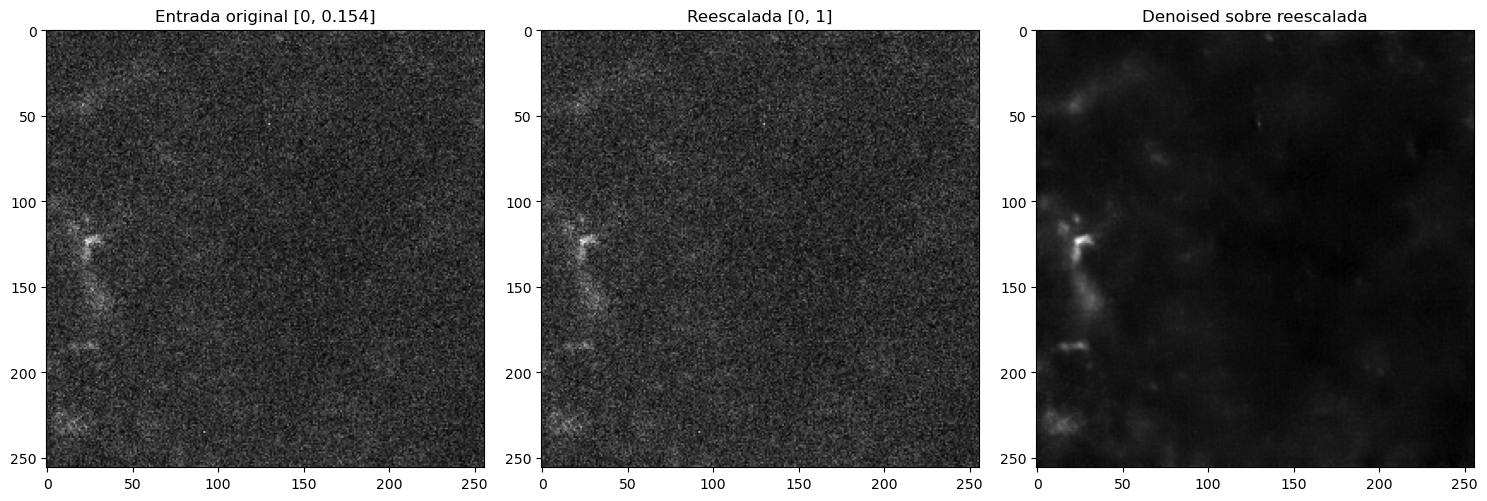

In [10]:
import tifffile, numpy as np
import matplotlib.pyplot as plt

ckpt_path = Path("results/denoising-poisson-fmdd-drunet/tif_output_2026_06_02-19_42_17/best_model.pth")

# # Cargar modelo con pesos FMDD
# base_model_fmdd = dinv.models.ArtifactRemoval(
#     dinv.models.DRUNet(in_channels=1, out_channels=1, pretrained=None, nc=[16, 32, 64, 128])
# ).to(device)
# criterion_fmdd = R2RLoss(noise_model=noise_model, alpha=0.15)
# model_fmdd = criterion_fmdd.adapt_model(base_model_fmdd)

# ckpt = torch.load(ckpt_path, map_location=device)
# state = ckpt.get("state_dict", ckpt)
# cleaned = {k[6:] if k.startswith("model.") else k: v 
#            for k, v in state.items() if not k.startswith("noise_model.")}
# model_fmdd.load_state_dict(cleaned, strict=False)
# print("Claves del checkpoint (primeras 3):", list(cleaned.keys())[:3])
# print("Claves del modelo (primeras 3):    ", list(model_fmdd.state_dict().keys())[:3])

# model_fmdd.eval()

# 1. Crear modelo base (sin envolver)
base_model_fmdd = dinv.models.ArtifactRemoval(
    dinv.models.DRUNet(in_channels=1, out_channels=1, pretrained=None, nc=[16, 32, 64, 128])
).to(device)

# 2. Cargar pesos en el modelo base
ckpt = torch.load(ckpt_path, map_location=device)
state = ckpt.get("state_dict", ckpt)
cleaned = {k[6:] if k.startswith("model.") else k: v
           for k, v in state.items() if not k.startswith("noise_model.")}
base_model_fmdd.load_state_dict(cleaned, strict=False)

# 3. Envolver con R2R DESPUÉS de cargar
criterion_fmdd = R2RLoss(noise_model=noise_model, alpha=0.15)
model_fmdd = criterion_fmdd.adapt_model(base_model_fmdd)
model_fmdd.eval()


# Inferencia sobre el primer batch
# with torch.no_grad():
#     x_est = model_fmdd(y, physics)

# Reescalar y al rango [0,1] antes de pasarlo al modelo FMDD
y_rescaled = y #/ (y.max() + 1e-8)

with torch.no_grad():
    x_est_rescaled = model_fmdd(y_rescaled, physics)

# Visualizar
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# axes[0].imshow(y[0, 0].cpu().numpy(), cmap="gray")
# axes[0].set_title("Entrada ruidosa")
# axes[1].imshow(x_est[0, 0].cpu().numpy(), cmap="gray")
# axes[1].set_title("Denoised (pesos FMDD)")
# plt.tight_layout()
# plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(y[0, 0].cpu().numpy(), cmap="gray")
axes[0].set_title(f"Entrada original [0, {y.max():.3f}]")
axes[1].imshow(y_rescaled[0, 0].cpu().numpy(), cmap="gray")
axes[1].set_title("Reescalada [0, 1]")
axes[2].imshow(x_est_rescaled[0, 0].cpu().numpy(), cmap="gray")
axes[2].set_title("Denoised sobre reescalada")
plt.tight_layout()
plt.show()


In [11]:
print(1e-4)
print(.1e-4)

0.0001
1e-05


In [ ]:
def add_saturation_patches(
    img: np.ndarray,
    n_patches_range: tuple = (3, 8),
    intensity_values: list = [240.0, 255.0, 320.0, 500.0],
    patch_size_range: tuple = (40, 80),
    min_mean_intensity: float = 20.0,
    save_path: str | Path | None = None,
    seed: int | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    img = np.asarray(img, dtype=np.float32)

    squeeze = img.ndim == 3 and img.shape[0] == 1
    if squeeze:
        img = img[0]

    H, W = img.shape
    modified = img.copy()
    occupied = np.zeros((H, W), dtype=bool)
    lo, hi = patch_size_range
    n_patches = rng.integers(n_patches_range[0], n_patches_range[1] + 1)

    placed = 0
    attempts = 0
    while placed < n_patches and attempts < 300:
        attempts += 1
        ph = rng.integers(lo, hi + 1)
        pw = rng.integers(lo, hi + 1)
        if H < ph or W < pw:
            continue
        y0 = rng.integers(0, H - ph + 1)
        x0 = rng.integers(0, W - pw + 1)

        if occupied[y0:y0+ph, x0:x0+pw].any():
            continue

        p_max = modified[y0:y0+ph, x0:x0+pw].max()
        p_mean = modified[y0:y0+ph, x0:x0+pw].mean()
        if p_max < 1.0 or p_mean < min_mean_intensity:
            continue

        target = rng.choice(intensity_values)
        modified[y0:y0+ph, x0:x0+pw] *= target / p_max
        occupied[y0:y0+ph, x0:x0+pw] = True
        placed += 1

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        iio.imwrite(str(save_path), modified)

    if squeeze:
        modified = modified[np.newaxis]

    return modified


Original:  min=3.0  max=255.0  mean=31.0
Modificada: min=3.0  max=320.0  mean=33.5


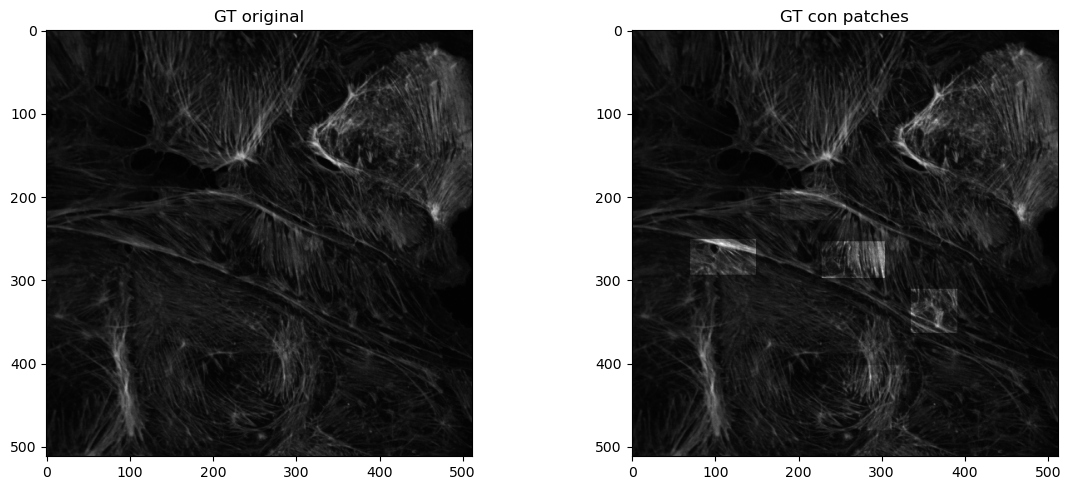

In [48]:
from pathlib import Path
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt

gt_path = Path("/home/diegosilvera/Escritorio/data/FMDD/Confocal_BPAE_G/gt/6/avg50.png")
raw_gt = iio.imread(gt_path).astype(np.float32)
if raw_gt.ndim == 3:
    raw_gt = raw_gt.mean(axis=-1)

SAVE_PATH = Path("results/saturation_experiment/Confocal_BPAE_G_gt6_modified.tif")

modified = add_saturation_patches(
    img=raw_gt,
    n_patches_range=(3, 8),
    intensity_values=[240.0, 255.0, 320.0, 500.0],
    patch_size_range=(40, 80),
    save_path=SAVE_PATH,
    seed=44,
)

print(f"Original:  min={raw_gt.min():.1f}  max={raw_gt.max():.1f}  mean={raw_gt.mean():.1f}")
print(f"Modificada: min={modified.min():.1f}  max={modified.max():.1f}  mean={modified.mean():.1f}")

vmax = modified.max()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(raw_gt, cmap="gray", vmin=0, vmax=vmax)
axes[0].set_title("GT original")
axes[1].imshow(modified, cmap="gray", vmin=0, vmax=vmax)
axes[1].set_title("GT con patches")
plt.tight_layout()
plt.show()


Grupo         N píxeles  Media denoised  Std denoised
-------------------------------------------------------
Saturados         7,997          254.07         16.27
Vecinos           7,573          150.31         76.14
Lejanos       1,033,006            7.43         12.12


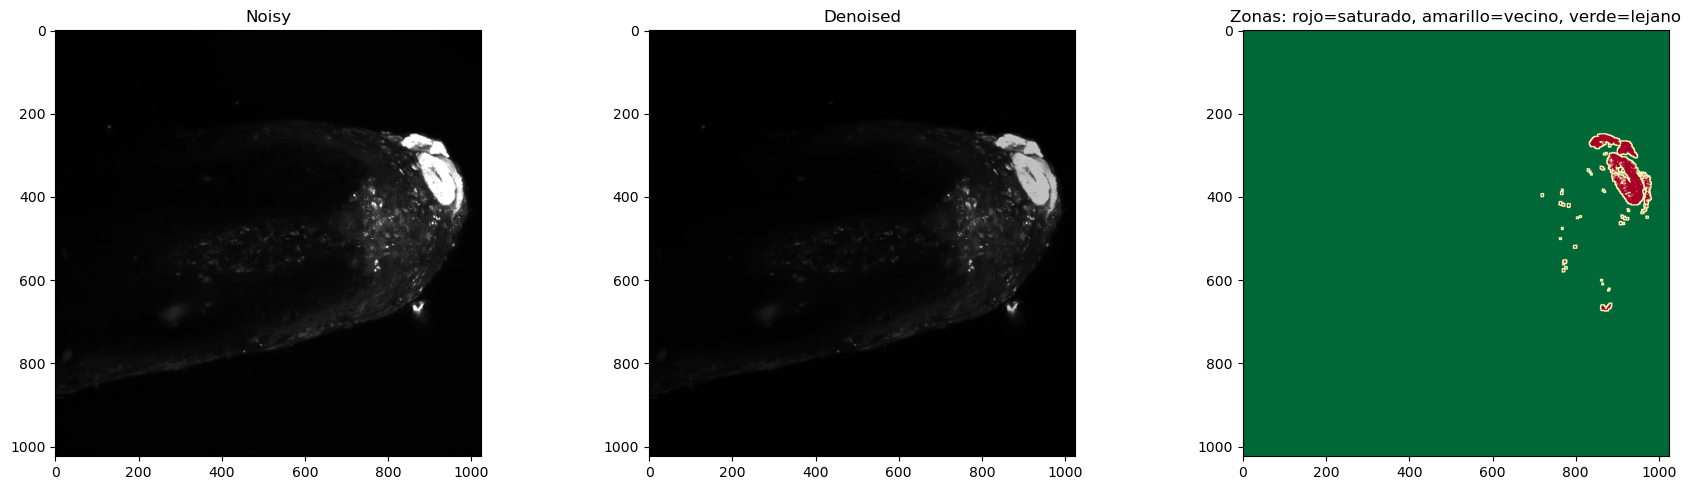

In [ ]:
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

# --- Parámetros: apuntar a los resultados que quieras analizar ---
base_dir = "/home/diegosilvera/Escritorio/GeneralizedR2R/results/inference/loreal_2026_06_04-13_24_41_splitted"
sample = "HF1_Bruite_1024pix_Ex780nm_10pc_LineAccu12.tif"
frame = "frame_0000.tif"

n = np.array(Image.open(f"{base_dir}/{sample}_dir_noisy/{frame}"), dtype=np.float32)
d = np.array(Image.open(f"{base_dir}/{sample}_dir_denoised/{frame}"), dtype=np.float32)

# --- Máscara de saturación ---
sat_threshold = 1.0   # para Loreal (normalizado). Para FMDD patched usar 1.0 también
mask_sat = n >= sat_threshold

# --- Dilatación manual (vecinos a radio r píxeles) ---
def dilate(mask, r=3):
    m = mask.copy()
    for _ in range(r):
        m[1:]  |= m[:-1]; m[:-1] |= m[1:]
        m[:, 1:] |= m[:, :-1]; m[:, :-1] |= m[:, 1:]
    return m

dilated    = dilate(mask_sat, r=3)
mask_neighbor = dilated & ~mask_sat
mask_far      = ~dilated

# --- Estadísticas ---
groups = {
    "Saturados":  mask_sat,
    "Vecinos":    mask_neighbor,
    "Lejanos":    mask_far,
}

print(f"{'Grupo':<12} {'N píxeles':>10} {'Media denoised':>15} {'Std denoised':>13}")
print("-" * 55)
for name, mask in groups.items():
    if mask.sum() == 0:
        print(f"{name:<12} {'—':>10}")
        continue
    vals = d[mask]
    print(f"{name:<12} {mask.sum():>10,} {vals.mean():>15.2f} {vals.std():>13.2f}")

# --- Visualización: mapa de zonas ---
zone_map = np.zeros_like(n, dtype=np.uint8)
zone_map[mask_far]      = 1   # gris
zone_map[mask_neighbor] = 2   # amarillo
zone_map[mask_sat]      = 3   # rojo

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(n, cmap="gray"); axes[0].set_title("Noisy")
axes[1].imshow(d, cmap="gray"); axes[1].set_title("Denoised")
axes[2].imshow(zone_map, cmap="RdYlGn_r", vmin=1, vmax=3)
axes[2].set_title("Zonas: rojo=saturado, amarillo=vecino, verde=lejano")
plt.tight_layout(); plt.show()


Lo de la std de los vecinos de la celda de arriba no me convence. No creo que diga mucho del denoising, por ahora lo descarto.